In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

In [3]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [4]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [5]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [6]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [8]:
case = '01021'

dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]
elif case[3] == '3':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-10], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '4':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-10], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '5':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-10], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
# get initial parameters and target states

i_range = [20, 50]
i_range_0 = i_range
i_range_1 = i_range
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  20 0.4500000000000001 0.4750000000000002
-------  50 0.47500000000000014 0.6000000000000003


In [12]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  20 0.4500000000000001 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12738.116450271265
Gradient descend method:  None
RUN  0 , total integrated cost =  12738.116450271265
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  50 0.47500000000000014 0.6000000000000003
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15942.955436075114
Gradient descend method:  None
RUN  0 , total integrated cost =  15942.955436075114
Improved over  0  iterations in  0.0  seconds by  0.0  percent.


In [13]:
aln.params.duration = dur
read_file = os.getcwd().split('data_shift')[0] + 'data' + os.sep + case[:2] + '1' + case[3:] + os.sep + 'control_init_' + case[:2] + '1' + case[3:] + '.pickle'
print(read_file)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    
    with open(read_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_read = load_array[0]
    print(bestControl_read[i].shape)
    print(bestControl_read[i][0,0,::200])

    bestControl_init[i] = np.zeros(( 1, 6, n_dur + n_pre + n_post -2 ))
    bestControl_init[i][:,:,n_pre-1:n_pre-1+2500] = bestControl_read[i][:,:,n_pre-1+1500:n_pre-1+4000].copy()

    weight_ = 1.
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0
    weights_init[i] = cost.getParams()
    
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

    with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                     costnode_init, weights_init], f)

C:\Users\Lena\Documents\neurolib\GUI\current\gui\data\01121\control_init_01121.pickle
-------  20 0.4500000000000001 0.4750000000000002
(1, 6, 4201)
[0.00000000e+00 5.23607824e-08 1.34567012e-07 3.45836714e-07
 8.88799096e-07 2.28421070e-06 5.87041554e-06 1.50869639e-05
 3.87735609e-05 9.96487058e-05 2.56102095e-04 6.58216444e-04
 1.69184546e-03 4.34957171e-03 1.11885932e-02 2.88238381e-02
 7.46058318e-02 1.99480164e-01 2.78862164e-01 4.85395695e-02
 7.55564509e-03 0.00000000e+00]
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  12741.961406640165
Gradient descend method:  None
RUN  0 , total integrated cost =  12741.961406640165
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -74.52557127348993 -74.52557729307314
-------  50 0.47500000000000014 0.6000000000000003
(1, 6, 4201)
[0.00000000e+00 2.82051207e-07 7.12483089e-07 1.79980573e-06
 4.54654218e-06 1.14852754e-05 2.90139138e-05 7.32953064e-05
 1.85161838e-04 4.67771263e-04 1.18174963e-03 2.98562471e-03
 7.54364200e-03 1.90650862e-02 4.82162237e-02 1.22140816e-01
 3.10943394e-01 7.91951145e-01 2.30991088e-01 2.99432210e-02
 2.29256494e-03 0.00000000e+00]
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11.049385948849238
Gradient descend method:  None
RUN  0 , total integrated cost =  11.049385948849238
Improved over  0  iterations in  0.0  seconds by  0.0  percent.


--------- 20


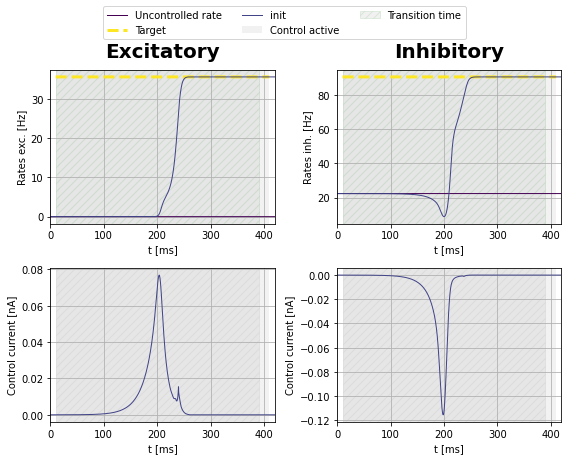

--------- 50


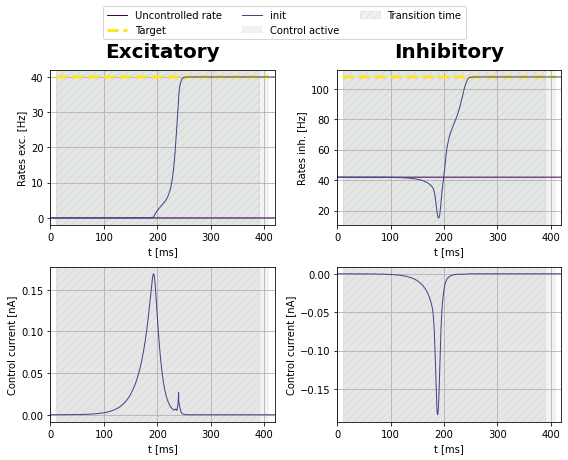

In [14]:
#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [15]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [16]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False
i_stepsize = 5

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

ERROR:root:Cost parameter I_e smaller 0 not allowed, use default instead


--------------- 0
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  20 0.4500000000000001 0.4750000000000002
weight =  -0.0003017554555529989
set cost params:  1.0 -0.0003017554555529989 -0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.6981565755905925
Gradient descend method:  None
RUN  1 , total integrated cost =  3.5578965062376704
RUN  2 , total integrated cost =  3.5569172229690627
RUN  3 , total integrated cost =  3.556889149904262
RUN  4 , total integrated cost =  3.556889121931819
RUN  5 , total integrated cost =  3.556889116499918
RUN  6 , total integrated cost =  3.5568

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1671 , total integrated cost =  3.55598833141759
Improved over  1671  iterations in  611.256539151  seconds by  3.844300295757435  percent.
Problem in initial value trasfer:  Vmean_exc -56.66905774712443 -56.66905811076794
no convergence
-------  50 0.47500000000000014 0.6000000000000003
weight =  1441.8815782053052
set cost params:  1.0 1441.8815782053052 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15931.906050126383
Gradient descend method:  None
RUN  1 , total integrated cost =  15742.609050994704
RUN  2 , total integrated cost =  15735.844955132416
RUN  3 , total integrated cost =  15735.78539075926
RUN  4 , total integrated cost =  15735.785236202068
RUN  5 , total integrated cost =  15735.78523598505
RUN  6 , total integrated cost =  15735.785235864325
RUN  7 , total integrated cost =  15735.785234554161
RUN  8 , total integrated cost =  15735.785233941953
RUN  9 , total integrated cost =  15735.785233857416
RU

ERROR:root:Problem in initial value trasfer


...

RUN  2 , total integrated cost =  12734.564835625975
Control only changes marginally.
RUN  2 , total integrated cost =  12734.564835625975
Improved over  2  iterations in  1.2133139939978719  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.66906699076899 -56.669066952340025
no convergence
-------  50 0.47500000000000014 0.6000000000000003
--------------- 19
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  20 0.4500000000000001 0.4750000000000002
weight =  3585.570538322318
set cost params:  1.0 3585.570538322318 0.0
interpolate adjoint :  True True True
RUN  0 , to

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  12734.564835625975
Control only changes marginally.
RUN  1 , total integrated cost =  12734.564835625975
Improved over  1  iterations in  0.6194500150013482  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66906699076899 -56.669066952340025
no convergence
-------  50 0.47500000000000014 0.6000000000000003
--------------- 20
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  20 0.4500000000000001 0.4750000000000002
weight =  3585.570538322318
set cost params:  1.0 3585.570538322318 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  12734.564835625975
Control only changes marginally.
RUN  1 , total integrated cost =  12734.564835625975
Improved over  1  iterations in  0.6196193650030182  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66906699076899 -56.669066952340025
converged for  20
-------  50 0.47500000000000014 0.6000000000000003
--------------- 21


In [17]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [18]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [19]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  20 0.4500000000000001 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.5526009218592574
Gradient descend method:  None
RUN  1 , total integrated cost =  3.5516280489640524
RUN  2 , total integrated cost =  3.5516280387324173
RUN  3 , total integrated cost =  3.5516280387016925
RUN  4 , total integrated cost =  3.551628038701535
RUN  5 , total integrated cost =  3.5516280387015304
RUN  6 , total integrated cost =  3.5516280387015287


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  3.5516280387015287
Control only changes marginally.
RUN  7 , total integrated cost =  3.5516280387015287
Improved over  7  iterations in  2.436301536996325  seconds by  0.027385095571602847  percent.
Problem in initial value trasfer:  Vmean_exc -56.66906804703081 -56.669067984255136
no convergence
-------  50 0.47500000000000014 0.6000000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.903379352151491
Gradient descend method:  None
RUN  1 , total integrated cost =  10.903288072779427
RUN  2 , total integrated cost =  10.903288072597435
RUN  3 , total integrated cost =  10.90328807259702
RUN  4 , total integrated cost =  10.903288072597013
RUN  5 , total integrated cost =  10.903288072597011
RUN  6 , total integrated cost =  10.903288072597011
Control only changes marginally.
RUN  6 , total integrated cost =  10.903288072597011
Improved over  6  iterations in  2.2126804430008633  seconds 

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.5516280387015287
Control only changes marginally.
RUN  1 , total integrated cost =  3.5516280387015287
Improved over  1  iterations in  0.5595561230002204  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66906804703081 -56.669067984255136
converged for  20
-------  50 0.47500000000000014 0.6000000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.903288072597011
Gradient descend method:  None
RUN  1 , total integrated cost =  10.903288072597011
Control only changes marginally.
RUN  1 , total integrated cost =  10.903288072597011
Improved over  1  iterations in  0.564766821997182  seconds by  0.0  percent.
converged for  50
--------------- 2
[[True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.5516280387015287
Control only changes marginally.
RUN  1 , total integrated cost =  3.5516280387015287
Improved over  1  iterations in  0.5567018770016148  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66906804703081 -56.669067984255136
converged for  20
-------  50 0.47500000000000014 0.6000000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.903288072597011
Gradient descend method:  None
RUN  1 , total integrated cost =  10.903288072597011
Control only changes marginally.
RUN  1 , total integrated cost =  10.903288072597011
Improved over  1  iterations in  0.5593620450017625  seconds by  0.0  percent.
converged for  50
--------------- 3
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]